## Introduction to Differential Equations

Jakob Bernoulli, around 1600s, was pondering about this problem:

Suppose you have ₹ 1 in a bank as the initial deposit and the bank pays 100 percent interest per year. At the end of the year it would be ₹2 if they calculate the interest yearly.

At the end of the year you are left with $(1 + 100\%\ interest\ on\ 1)$ = ₹ 2 . 

If, on the other hand, the bank calculate the interests twice a year with the second calculation of interest at the end of the year taking into consideration the principal amount as well as the interest accrued to it in the first half of the year, you would end up with little more than  ₹ 2. We can calculate the exact amount as follows:
Let's call the principal amount plus the interest from the half year as M1.

$M_{half} = (1+\frac{r}{2})M_{initial}$

$M_{full} = (1+\frac{r}{2})M_{half}$

$M_{full} = (1+\frac{r}{2})(1+\frac{r}{2})M_{initial}$

$M_{full} = (1+\frac{r}{2})^{2}M_{initial}$

here, for 100% interest rate per year, the value or r is 1. 



In [2]:
Mi = 1
r = 1
Mf = (1+r/2)^2*Mi 

2.25

For a bank that copounds interests quaterly, we will end up with  $(1+\frac{r}{3})^{3}M_{initial}$

In [4]:
Mf = (1+r/3)^3*Mi 

2.3703703703703702

This is what Bernoulli observed. As we shrink the time period over which the compound interest is calculated for a fixed yearly rate of interests, the amount at the end of the year always increases but the subsequent increment are getting smaller and smaller as we increase the number of ever shrinking time intervals. He observed the total sum to be converging onto a number between 2 and 3 that we denote as e today.   

In [5]:
comp_int(n) = (1+r/n)^n*Mi

comp_int (generic function with 1 method)

In [11]:
comp_int(5000)

2.7180100501015545

For a generic annual interest rate, we can write the following function

In [13]:
comp_int_general(n, r, Mi) = (1+r/n)^n*Mi

comp_int_general (generic function with 1 method)

In [23]:
comp_int_general(500, 1, 10)

27.155685206517283

## Continuous compounding

$$
\begin{split}
M_{t_{N}} = (1+rh)M_{t_{N-1}}\\
h = (t_{N} - t_{N-1})
\end{split}
$$

We can talk about the difference in the amount of money between successive time points at which the compounding is accomplished.

$$
\begin{split}
M_{t_{N}} - M_{t_{N-1}} = rhM_{t_{N-1}}\\
\end{split}
$$

We can talk about the growth rate per unit time

$$
\begin{split}
\frac{M_{t_{N}} - M_{t_{N-1}}}{h} = rM_{t_{N-1}}\\
\end{split}
$$


The instantaneous growth rate is what the above converges to as we make the time interval, h, ever so small. Now we end up with a differential equation that relates the instantaneous growth rate to the amount of money present at the moment. For the continous compounding, it tells us that the instantaneous growth rate is proportional to the amount of money in the bank and the propotionality constant is the interest rate (time in years).

$$
\begin{split}
\frac{dM(t)}{dt} = \lim{h \to 0}{\frac{M_{t_{N}} - M_{t_{N-1}}}{h}} = rM(t)\\
\end{split}
$$
For brevity, after assuming the dependence of M on t, we write the differential equation succinctly as follows
$$
\frac{dM}{dt} = rM 
$$


Conside this question: If we deposit ₹ 1000 at the beginning and the interest rate, r is 0.2, and we wait for 10 years, what is the amount of money in our bank, if they follow continous compounding as espoused by the differential equation above.

When we model phenomena using diffential equations, the question we posed above constitute an initial value problem:
1) There is an initial value
2) There is a differential equation modeling the evolution of the variable (Money here) of interest over time (as is the case here) or space that are continuous in nature. The differential equation also has one or more parameters

In our case the initial value problem has an explicit solution, i.e, we can write down the evolution of the variable as a function of time using known mathematical functions. It is

$M(t) = M_0e^{rt}$,

where $M_0$ is the initially invested amount of money and t is the elapsed time since then.
 

In [30]:
## Solution to the initial value problem
## M_0 = 1000
## dM/dt = rM
r = 0.2
money_beginning = 1000
money_now(t) = money_beginning*exp(r*t)

money_now (generic function with 1 method)

In [31]:
r

0.2

In [33]:
money_now(10)

7389.0560989306505

We can see the evolution of our money over the years

In [48]:
#Years going from 0 to 10 with in 1 year steps
years = 0:10 
#Elementwise mapping of the function money_now to the array of years
map(money_now, years) 

11-element Vector{Float64}:
 1000.0
 1221.40275816017
 1491.8246976412704
 1822.118800390509
 2225.540928492468
 2718.2818284590453
 3320.116922736548
 4055.1999668446756
 4953.0324243951145
 6049.647464412947
 7389.0560989306505

In [45]:
## Or we can do this 
money_now.(years)

11-element Vector{Float64}:
 1000.0
 1221.40275816017
 1491.8246976412704
 1822.118800390509
 2225.540928492468
 2718.2818284590453
 3320.116922736548
 4055.1999668446756
 4953.0324243951145
 6049.647464412947
 7389.0560989306505

## Numerical Integration

As we will see in subsequent examples, not all of the differential equations are in the form where they can have explicit solution as our example above. We can write explicit solutions for all the linear differential equations (where the term on the right hand side has the variable as a part of linear expressions, i.e, no powers greater than one and no products of two or more variables) and for some few nonlinear differential equations. But, most of the nonlinear differential equations do not have explicit solutions we can write down. In those scenarios, which is almost always when we are modeling natural phenomena, we have to turn to numerical integration of differential equations to find answers to the initial value probems. It is imperative we gain a basic intuition of numerical integration with our simple problem and learn to use solvers julia language offers on it as well. 

Recall our ODE (Ordinary Differential equations):

$$
\begin{split}
\frac{dM}{dt} = rM
\end{split}
$$

We have seen an approximation to this equation as well:

$$
\begin{split}
\frac{M_{t_{N}} - M_{t_{N-1}}}{h} = rM_{t_{N-1}}\\
\end{split}
$$

This approximation can be put to use to find the value of the variable in the next time step ($M_{t_{N}}$ at time $t_{N}$) given its value in the current time step ($M_{t_{N-1}}$ at time $t_{N-1}$) as follows,

$$
\begin{split}
M_{t_{N}} =  M_{t_{N-1}} + h*rM_{t_{N-1}}\\
\end{split}
$$



In [49]:
## Let's define the rhs as follows
function rhs(m_at_t, r)
    dmbydt = r*m_at_t 
    return dmbydt
end

rhs (generic function with 1 method)

In [68]:
## Our initial investment/initial condition
m_at_t0 = 1000
## Our time step. We will find solutions at successive time steps
dt = h = 0.2 ## pick a reasonably small time interval#

## Times at which we are looking for our solutions
t_start = 0
t_end = 10
times_vec = range(t_start,t_end,step=dt)

#We are going to create an empty vector of the same size as the time vector
#We will fill up this vector with the approximate solutions as we go along 
#integrating our rhs in our loop
sol_vec = zeros(length(times_vec))


#We will fill the first slot in solution with our initial condition ma_at_t0
sol_vec[1] = m_at_t0

## We are iteratively finding the successive values of our solution (amount of money at successive steps)
## using our approximation formula above, m_at_nextstep = m_at_current_step + h*rhs(m_at_current_step)
for (iter_now, t_now) in enumerate(times_vec[1:length(times_vec)-1])
    sol_vec[iter_now+1] = sol_vec[iter_now] + dt*rhs(sol_vec[iter_now], r)
    println(iter_now,"\t",t_now, "\t", sol_vec[iter_now])
end
    


1	0.0	1000.0
2	0.2	1040.0
3	0.4	1081.6
4	0.6	1124.8639999999998
5	0.8	1169.85856
6	1.0	1216.6529024
7	1.2	1265.319018496
8	1.4	1315.93177923584
9	1.6	1368.5690504052736
10	1.8	1423.3118124214845
11	2.0	1480.244284918344
12	2.2	1539.4540563150777
13	2.4	1601.0322185676807
14	2.6	1665.0735073103879
15	2.8	1731.6764476028034
16	3.0	1800.9435055069155
17	3.2	1872.9812457271921
18	3.4	1947.9004955562798
19	3.6	2025.816515378531
20	3.8	2106.8491759936724
21	4.0	2191.123143033419
22	4.2	2278.768068754756
23	4.4	2369.918791504946
24	4.6	2464.715543165144
25	4.8	2563.3041648917497
26	5.0	2665.8363314874196
27	5.2	2772.4697847469165
28	5.4	2883.3685761367933
29	5.6	2998.703319182265
30	5.8	3118.651451949556
31	6.0	3243.397510027538
32	6.2	3373.1334104286393
33	6.4	3508.0587468457848
34	6.6	3648.381096719616
35	6.8	3794.3163405884006
36	7.0	3946.0889942119366
37	7.2	4103.932553980414
38	7.4	4268.089856139631
39	7.6	4438.813450385216
40	7.8	4616.365988400625
41	8.0	4801.020627936649
42	8.2	4993.06

We can find how good of an approximation our clever method achieved by comparing the numerical solution with the explicit solution we found before.

In [69]:
## We are going to use this graphical plotting library
using CairoMakie

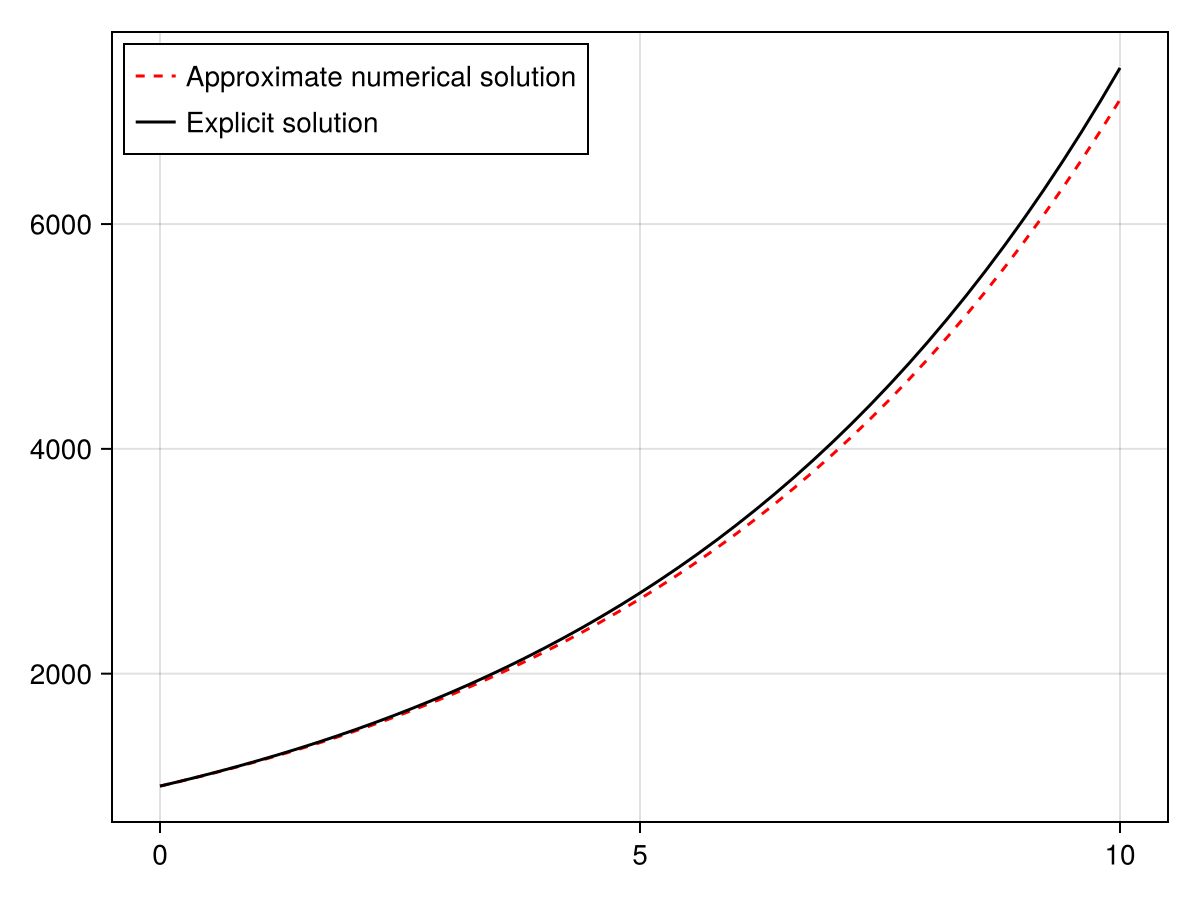

In [73]:
lines(times_vec, sol_vec, color=:red, linestyle=:dash, label="Approximate numerical solution")
lines!(times_vec, money_now.(times_vec), color=:black, label="Explicit solution")

axislegend(position = :lt)
ax = current_axis()
ax.xlabel="Time (in years)"
ax.ylabel="Amount of money (in rupee)"
current_figure()

We can improve the accuracy of the method with the smaller time steps which will also increase the simulation run time as there will be more iteration and computation of the rhs side for a given span of time.

In [82]:
## Refactoring our code into a function so that it can be run for many different stepsize, h or dt, parameter.
function my_solver(rhs, init_cond, tspan, dt, param)
    
    ## Our initial investment/initial condition
    m_at_t0 = init_cond
    ## Our time step. We will find solutions at successive time steps
    #dt = h = 0.2 ## pick a reasonably small time interval#
    
    ## Times at which we are looking for our solutions
    t_start = tspan[1]
    t_end = tspan[2]
    times_vec = range(t_start,t_end,step=dt)
    
    #We are going to create an empty vector of the same size as the time vector
    #We will fill up this vector with the approximate solutions as we go along 
    #integrating our rhs in our loop
    sol_vec = zeros(length(times_vec))
    
    
    #We will fill the first slot in solution with our initial condition ma_at_t0
    sol_vec[1] = m_at_t0
    
    ## We are iteratively finding the successive values of our solution (amount of money at successive steps)
    ## using our approximation formula above, m_at_nextstep = m_at_current_step + h*rhs(m_at_current_step)
    for (iter_now, t_now) in enumerate(times_vec[1:length(times_vec)-1])
        sol_vec[iter_now+1] = sol_vec[iter_now] + dt*rhs(sol_vec[iter_now], param)
        # println(iter_now,"\t",t_now, "\t", sol_vec[iter_now])
    end
    sol_dict = Dict()
    sol_dict["t"] = times_vec
    sol_dict["m"] = sol_vec
    return sol_dict
end

my_solver (generic function with 1 method)

In [83]:
using Printf

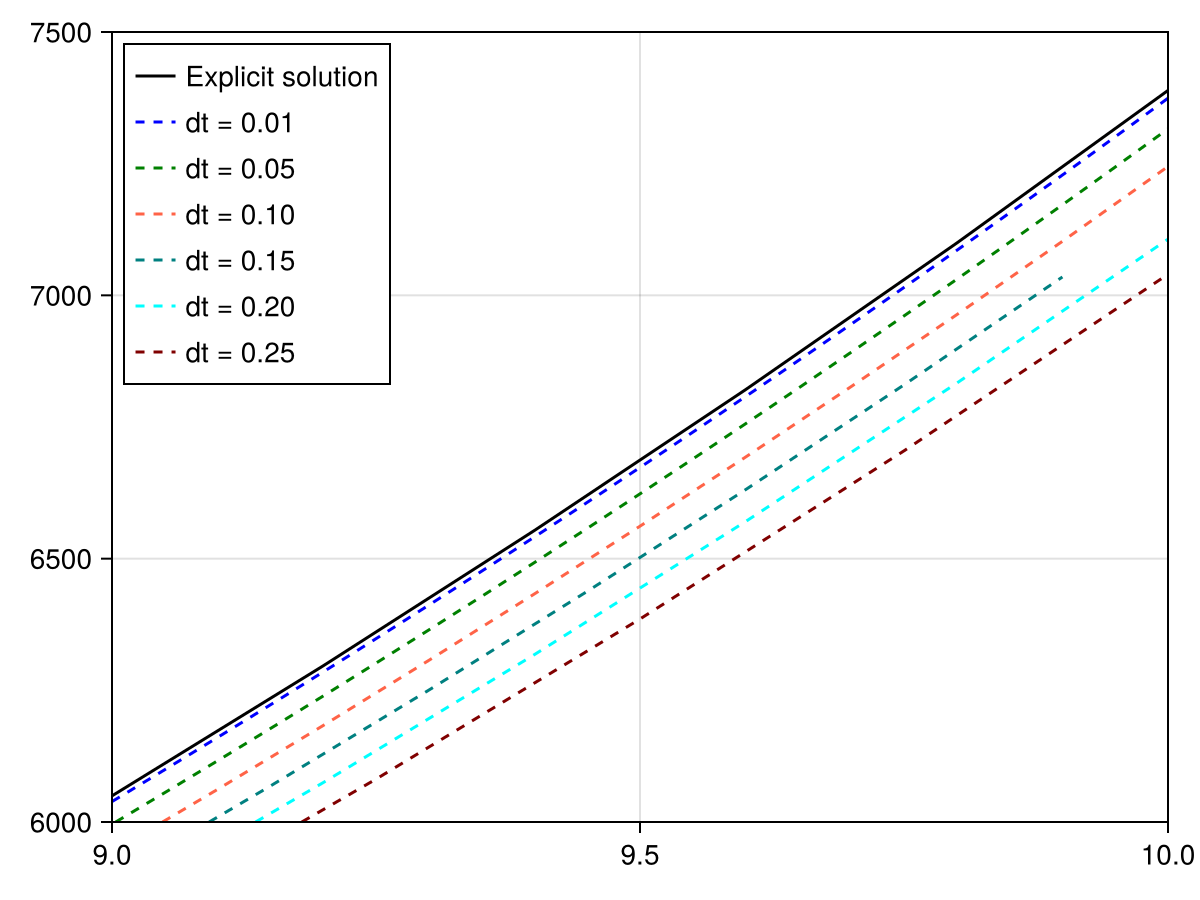

In [89]:
m_at_t0 = 1000.0
dt = 0.4
r = 0.2
tspan = (0,10)

lines(times_vec, money_now.(times_vec), color=:black, label="Explicit solution")

colors = [:blue, :green, :tomato, :teal, :cyan, :maroon]
for (iter_, dt) in enumerate([0.01,0.05,0.1,0.15,0.2,0.25])
    sol_d = my_solver(rhs, m_at_t0, tspan, dt, r);
    lines!(sol_d["t"], sol_d["m"], color=colors[iter_], linestyle=:dash, label=@sprintf("dt = %.2f", dt))
end
ylims!(6000,7500)
xlims!(9,10)
axislegend(position = :lt)
current_figure()